# **1. 준비된 Custom Dataset 가져오기**

**1-1. 데이터 가져오기**
- VM에 dataset2.zip 파일로 업로드 후 압축 풀기

In [1]:
import zipfile

with zipfile.ZipFile('/content/dataset2.zip') as target_file:
    target_file.extractall('/content/dataset')

- 원시 데이터셋의 개수

In [2]:
import os

# 이미지 파일(.jpg)만 필터링하여 개수 카운팅 함수
def count_images_in_folder(folder_path, extension=".jpg"):
    return len([file for file in os.listdir(folder_path) if file.endswith(extension)])

# 폴더 경로
source_folder = '/content/dataset'

# 이미지 개수 카운팅
source_image_count = count_images_in_folder(source_folder, extension=".jpg")
print(f"Source folder contains {source_image_count} image(s).")

Source folder contains 20 image(s).


**1-2. 데이터 증식시키기**

In [3]:
import os
import json
import cv2
import albumentations as A
import numpy as np
import base64

# 증식 설정: 다양한 변환 추가
transform = A.Compose([
    A.HorizontalFlip(p=0.5), # 수평 뒤집기
    A.VerticalFlip(p=0.3), # 수직 뒤집기
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.7), # 이동/확대/회전
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5), # 밝기/대비 조정
    A.MotionBlur(blur_limit=(3, 5), p=0.2), # 모션 블러
    A.GaussianBlur(blur_limit=(3, 5), p=0.2), # 가우시안 블러
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5), # 색조/채도/밝기 조정
], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False), # 여기서 False로 설정
   additional_targets={'mask': 'mask'})

# 폴더 경로 설정
input_base_path = '/content/dataset'
output_base_path = '/content/aug_dataset'
os.makedirs(output_base_path, exist_ok=True)

# 각 이미지당 증식할 횟수 지정
n_copies = 25

# 이미지 및 어노테이션 파일 로드
file_list = os.listdir(input_base_path)
image_files = [f for f in file_list if f.endswith('.jpg')]
annotation_files = [f.replace('.jpg', '.json') for f in image_files]

for image_file, annotation_file in zip(image_files, annotation_files):
    # 이미지 로드
    image_path = os.path.join(input_base_path, image_file)
    annotation_path = os.path.join(input_base_path, annotation_file)
    image = cv2.imread(image_path)

    # Labelme JSON 파일 로드
    with open(annotation_path, 'r') as f:
        annotations = json.load(f)

    shapes = annotations.get('shapes', [])  # Labelme의 shapes 키
    image_height = annotations['imageHeight']
    image_width = annotations['imageWidth']

    # Polygon 데이터를 키포인트로 변환
    keypoints = []
    labels = []
    for shape in shapes:
        if shape['shape_type'] == 'polygon':
            points = shape['points']
            keypoints.append(np.array(points).reshape(-1, 2).tolist())
            labels.append(shape['label'])

    # Polygon이 없는 경우 스킵
    if not keypoints:
        print(f"Warning: No polygons found in {annotation_file}. Skipping.")
        continue

    # 증식 반복 (예: 5배 증식)
    for i in range(n_copies):
        # 마스크 생성
        mask = np.zeros((image_height, image_width), dtype=np.uint8)
        for shape in shapes:
            if shape['shape_type'] == 'polygon':
                points = np.array(shape['points'], dtype=np.int32)
                cv2.fillPoly(mask, [points], 255)

        augmented = transform(
            image=image,
            keypoints=np.concatenate(keypoints, axis=0) if keypoints else [],
            mask=mask
        )
        aug_image = augmented['image']
        aug_keypoints = augmented['keypoints']
        aug_mask = augmented['mask']

        # Keypoints를 Polygon으로 복원
        aug_shapes = []
        idx = 0
        for shape in shapes:
            if shape['shape_type'] == 'polygon':
                num_points = len(shape['points'])
                aug_polygon = aug_keypoints[idx:idx + num_points]
                aug_shapes.append({
                    "label": shape['label'],
                    "points": np.array(aug_polygon).tolist(),  # numpy 배열을 list로 변환
                    "group_id": shape.get('group_id'),
                    "shape_type": shape['shape_type'],
                    "flags": shape.get('flags', {})
                })
                idx += num_points

        # 증식된 이미지 저장
        aug_image_name = f"{os.path.splitext(image_file)[0]}_aug_{i}.jpg"
        aug_image_path = os.path.join(output_base_path, aug_image_name)
        cv2.imwrite(aug_image_path, aug_image)

        # 이미지 파일을 Base64로 인코딩
        with open(aug_image_path, "rb") as img_file:
            encoded_string = base64.b64encode(img_file.read()).decode('utf-8')

        # 증식된 어노테이션 저장
        aug_annotation_name = f"{os.path.splitext(annotation_file)[0]}_aug_{i}.json"
        aug_annotation_path = os.path.join(output_base_path, aug_annotation_name)
        aug_annotations = {
            "version": annotations['version'],
            "flags": annotations['flags'],
            "shapes": aug_shapes,
            "imagePath": aug_image_name,
            "imageData": encoded_string,  # Base64 인코딩된 이미지 데이터
            "imageHeight": image_height,
            "imageWidth": image_width
        }
        with open(aug_annotation_path, 'w') as f:
            json.dump(aug_annotations, f, indent=4)

print("Data augmentation for Labelme format completed!")

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Data augmentation for Labelme format completed!


- 증식한 데이터셋의 개수

In [4]:
import os

# 이미지 파일(.jpg)만 필터링하여 개수 카운팅 함수
def count_images_in_folder(folder_path, extension=".jpg"):
    return len([file for file in os.listdir(folder_path) if file.endswith(extension)])

# 폴더 경로
aug_folder = '/content/aug_dataset'

# 이미지 개수 카운팅
aug_image_count = count_images_in_folder(aug_folder, extension=".jpg")
print(f"Augmentation folder contains {aug_image_count} image(s).")

Augmentation folder contains 500 image(s).


**1-3. 증식데이터 시각화**

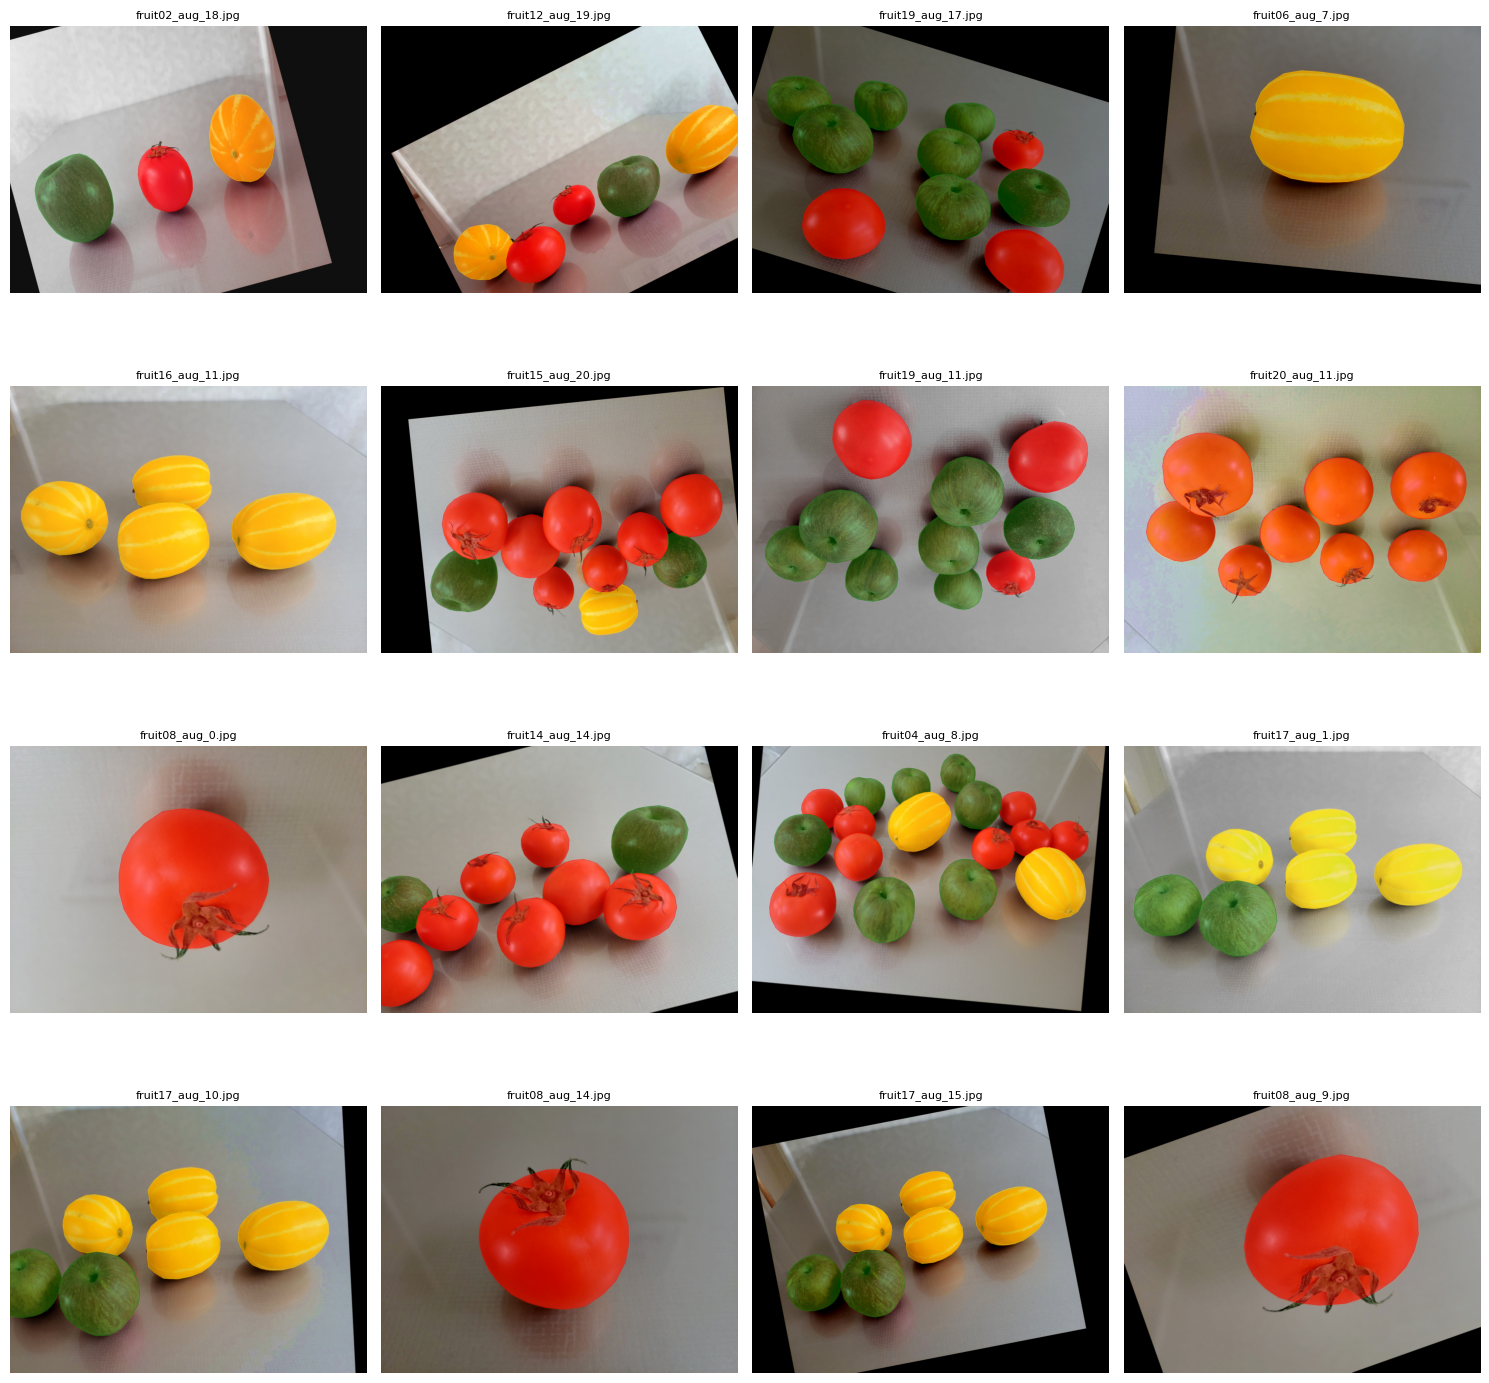

In [6]:
import os
import random
import matplotlib.pyplot as plt
import json
from PIL import Image, ImageDraw

# 투명 마스크를 그리는 함수
def draw_mask_with_alpha(image_path, json_path, alpha=100): # alpha: 0~255 (100은 약 40%)
    with open(json_path, 'r') as f:
        data = json.load(f)

    # 원본 이미지를 RGBA로 변환
    base_image = Image.open(image_path).convert("RGBA")
    # 마스크를 그릴 투명한 레이어 생성
    mask_layer = Image.new("RGBA", base_image.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(mask_layer)

    for shape in data['shapes']:
        label = shape['label']
        if label == 'Oriental melon':
            color = (255, 215, 0) # Gold
        elif label == 'Tomato':
            color = (255, 0, 0)   # Red
        elif label == 'Apple':
            color = (0, 128, 0)   # Green
        else:
            color = (128, 128, 128) # Gray

        # 폴리곤 좌표 변환
        polygon = [(point[0], point[1]) for point in shape['points']]

        # 투명도 적용: fill 색상에 alpha 값 추가
        draw.polygon(polygon, outline=color + (255,), fill=color + (alpha,))

    # 두 레이어 합성
    combined = Image.alpha_composite(base_image, mask_layer)
    return combined.convert("RGB") # 최종 출력을 위해 RGB로 복귀

# 4x4 그리드 시각화
def visualize_augmented_samples(image_paths):
    fig, axs = plt.subplots(4, 4, figsize=(15, 15))
    axs = axs.flatten()

    for img_path, ax in zip(image_paths, axs):
        json_path = img_path.replace('.jpg', '.json')

        if os.path.exists(json_path):
            image_with_mask = draw_mask_with_alpha(img_path, json_path, alpha=120)
            ax.imshow(image_with_mask)
        else:
            ax.imshow(Image.open(img_path))

        # 타이틀을 파일명으로 설정
        ax.set_title(os.path.basename(img_path), fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

augmented_image_files = [os.path.join(output_base_path, f) for f in os.listdir(output_base_path) if f.endswith('.jpg')]

random_images_for_visualization = random.sample(augmented_image_files, 16)
visualize_augmented_samples(random_images_for_visualization)

**1-4. labelme 포멧을 YOLO 포멧으로 변환**

In [7]:
!pip install labelme2yolo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 19.5 MB/s eta 0:00:00


In [8]:
!labelme2yolo --json_dir /content/aug_dataset --val_size 0.2 --output_format polygon  # --output_format bbox 또는 polygon(default는 bbox)

[2026-03-08T10:04:27Z INFO  labelme2yolo] Starting the conversion process...
[2026-03-08T10:04:27Z INFO  labelme2yolo::yolo_dataset] Processing JSON files in streaming fashion...
⠁ [00:00:00] [Processing JSON files] 
⠁ [00:00:00] [Processing JSON files] Processing files...
⠉ [00:00:00] [Processing JSON files] Processed 100 files...
⠉ [00:00:00] [Processing JSON files] Processed 200 files...
⠙ [00:00:00] [Processing JSON files] Processed 300 files...
⠚ [00:00:00] [Processing JSON files] Processed 400 files...
⠚ [00:00:00] [Processing JSON files] Processed 400 files...
  [00:00:00] [Processing JSON files] Processed 500 files...
[2026-03-08T10:04:27Z INFO  labelme2yolo::yolo_dataset] Processed 500 JSON files.
[2026-03-08T10:04:27Z INFO  labelme2yolo::types] === Processing Summary ===
[2026-03-08T10:04:27Z INFO  labelme2yolo::types] Total files processed: 500
[2026-03-08T10:04:27Z INFO  labelme2yolo::types] Successful conversions: 500
[2026-03-08T10:04:27Z INFO  labelme2yolo::types] Skippe

In [9]:
# 폴더의 내용을 tree 구조로 볼 수 있도록 하는 패키지 설치
!apt-get install tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 37 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (157 kB/s)
Selecting previously unselected package tree.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [10]:
yolo_root = "/content/aug_dataset/YOLODataset"
print("YOLO Dataset 구조 :\n")
!tree {yolo_root} -d

YOLO Dataset 구조 :

/content/aug_dataset/YOLODataset
├── images
│   ├── train
│   └── val
└── labels
    ├── train
    └── val

6 directories


**1.5 yaml파일 확인하기**
  - yaml 파일은 모델학습에 사용되는 데이터의 위치, 클래스의 수, 클래스명의 정보를 가지고 있다.
  - labelme2yolo로 변환되면서 클래스의 번호가 바뀔 수 있음에 주의

In [11]:
!cat /content/aug_dataset/YOLODataset/dataset.yaml

path: /content/aug_dataset/YOLODataset
train: images/train
val: images/val
test:

names:
    0: Apple
    1: Tomato
    2: Oriental melon


# **2. Custom yaml 파일을 만들자.**

In [12]:
# PyYAML을 설치하자
!pip install PyYAML

In [13]:
import yaml

data_cf = {'train' : '/content/aug_dataset/YOLODataset/images/train',
           'val' : '/content/aug_dataset/YOLODataset/images/val',
           'names' : ["Apple", "Tomato", "Oriental melon"],
           'nc' : 3 }

# fruit_data.yaml 이란 이름으로 custom yaml 파일을 만든다.
with open('/content/aug_dataset/YOLODataset/fruit_data.yaml', 'w') as f:
  yaml.dump(data_cf, f)

# fruit_data.yaml 확인
with open('/content/aug_dataset/YOLODataset/fruit_data.yaml', 'r') as f:
  fruit_yaml = yaml.safe_load(f)
  display(fruit_yaml)

{'names': ['Apple', 'Tomato', 'Oriental melon'],
 'nc': 3,
 'train': '/content/aug_dataset/YOLODataset/images/train',
 'val': '/content/aug_dataset/YOLODataset/images/val'}

# **3. YOLO26을 사용하기 위한 Setup(셋업)**

In [14]:
# ultralytics 설치
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.6 MB/s eta 0:00:00


In [15]:
# ultralytics 를 불러오고 체크
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.0/112.6 GB disk)


# **4. Custom YOLO Training(학습)**

**Segmentation 모델로 사용할 수 있는 모델의 종류**

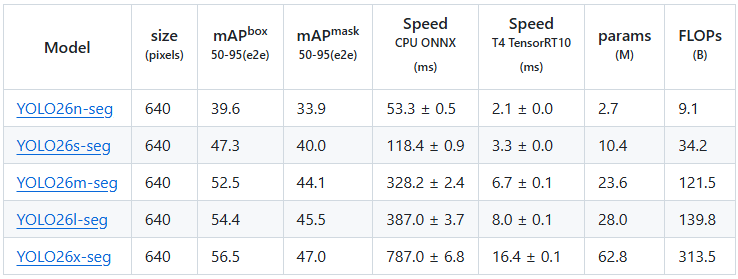

In [16]:
# ultralytics에서 YOLO 모듈을 불러옴
from ultralytics import YOLO
# yolo26n-seg.pt 모델의 아키텍처와 가중치을 함께 불러옴
model = YOLO('yolo26n-seg.pt')

In [17]:
# 모델이 분류할 수 있는 부류의 수 확인
print(type(model.names), len(model.names))
# 모델이 분류할 수 있는 부류 확인
print(model.names)

<class 'dict'> 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell p

**불러온 모델 아키텍처를 이용하여 우리가 준비한 Custom Dataset으로 학습을 시켜보자.**

In [18]:
model.train(data='/content/aug_dataset/YOLODataset/fruit_data.yaml', epochs=100, patience=10, batch=8, imgsz=640)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/aug_dataset/YOLODataset/fruit_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aeffc1cdeb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04

# **5. Training(학습) 결과 확인**

**학습 결과를 그래프로 저장한 파일을 통해 확인해 본다**

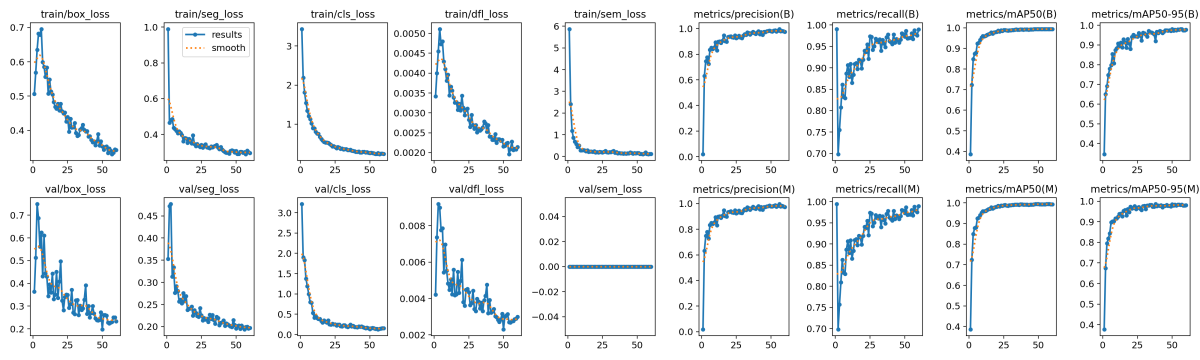

In [19]:
import cv2
from google.colab.patches import cv2_imshow

result_img = cv2.imread('/content/runs/segment/train/results.png')
fix_width = 1200
height,width = result_img.shape[:2]
ratio = fix_width / width
demension = (fix_width, int(height*ratio))
result_img = cv2.resize(result_img, demension, interpolation=cv2.INTER_AREA)
cv2_imshow(result_img)

**Custom 모델이 분류할 수 있는 부류 확인**

In [20]:
# 모델이 분류할 수 있는 부류의 수 확인
print(type(model.names), len(model.names))
# 모델이 분류할 수 있는 부류 확인
print(model.names)

<class 'dict'> 3
{0: 'Apple', 1: 'Tomato', 2: 'Oriental melon'}


# **6. Custom 모델로 Segmentation(분할)**

**Image Segmentation**

In [21]:
# 모델 예측
results = model.predict(source='/content/aug_dataset/YOLODataset/images/val/fruit03_aug_17_983a227b.jpg', save=True)


image 1/1 /content/aug_dataset/YOLODataset/images/val/fruit03_aug_17_983a227b.jpg: 480x640 2 Apples, 2 Tomatos, 2 Oriental melons, 75.0ms
Speed: 2.5ms preprocess, 75.0ms inference, 8.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/segment/predict


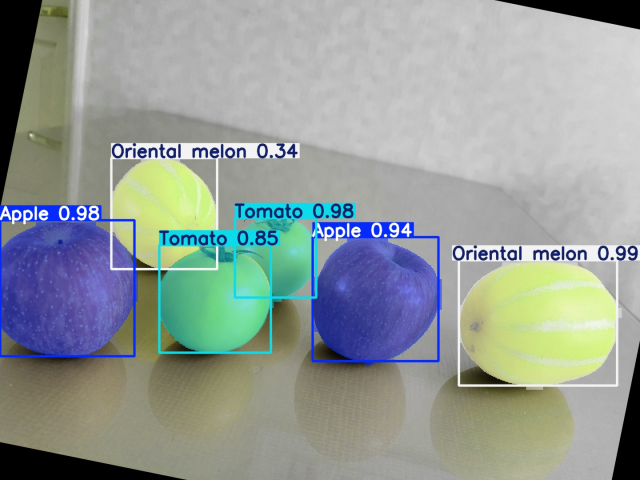

In [22]:
# 예측 이미지 확인
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/runs/segment/predict/fruit03_aug_17_983a227b.jpg')
fix_width = 640
height,width = img.shape[:2]
ratio = fix_width / width
demension = (fix_width, int(height*ratio))
img = cv2.resize(img, demension, interpolation=cv2.INTER_AREA)
cv2_imshow(img)

**Video Segmentation**

In [23]:
# 동영상 예측
results = model.predict(source='/content/fruit.mp4', save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/892) /content/fruit.mp4: 384x640 1 Apple, 1 Oriental melon, 81.1ms
video 1/1 (frame 2/892) /content/fruit.mp4: 384x640 2 Apples, 1 Oriental melon, 14.3ms
video 1/1 (frame 3/892) /content/fruit.mp4: 384x640 1 Apple, 1 Oriental melon, 23.6ms
video 1/1 (frame 4/892) /content/fruit.mp4: 384x640 1 Apple, 1 Tomato, 1 Oriental melon, 14.7ms
video 1/1 (frame 5/892) /content/fruit.mp4: 384x640 1 Apple, 1 Tomato, 1 Oriental melon, 13.6ms
video 1

In [24]:
# 코랩에서 영상을 보여줄 준비
import io
from IPython.display import HTML
from base64 import b64encode
def show_video(file_name, width=640):
  # show resulting deepsort video
  mp4 = open(file_name,'rb').read()
  data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
  return HTML("""
  <video width="{0}" controls>
        <source src="{1}" type="video/mp4">
  </video>
  """.format(width, data_url))

In [25]:
# avi 파일을 mp4 파일로 변환 후 영상을 보여줌
import os
path_video = os.path.join("/content/runs/segment/predict","fruit.avi")
%cd /content/runs/segment/predict
import locale
locale.getpreferredencoding = lambda: "UTF-8"
!ffmpeg -y -loglevel panic -i "fruit.avi" "fruit.mp4"
%cd ../../../

# output object tracking video
path_output = os.path.join("/content/runs/segment/predict","fruit.mp4")
show_video(path_output, width=640)

Output hidden; open in https://colab.research.google.com to view.

# **7. 학습된 모델을 불러와 검출**

In [26]:
# ultralytics 설치
!pip install ultralytics

# ultralytics 를 불러오고 체크
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.1/112.6 GB disk)


In [27]:
# ultralytics에서 YOLO 모듈을 불러옴
from ultralytics import YOLO
# 학습된 모델의 아키텍처와 가중치을 함께 불러옴
model = YOLO('/content/runs/segment/train/weights/best.pt')

In [28]:
# 모델이 분류할 수 있는 부류의 수 확인
print(type(model.names), len(model.names))
# 모델이 분류할 수 있는 부류 확인
print(model.names)

<class 'dict'> 3
{0: 'Apple', 1: 'Tomato', 2: 'Oriental melon'}


In [29]:
# 모델 예측
results = model.predict(source='/content/aug_dataset/YOLODataset/images/val/fruit03_aug_17_983a227b.jpg', save=True)


image 1/1 /content/aug_dataset/YOLODataset/images/val/fruit03_aug_17_983a227b.jpg: 480x640 2 Apples, 2 Tomatos, 2 Oriental melons, 51.8ms
Speed: 9.7ms preprocess, 51.8ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/segment/predict2


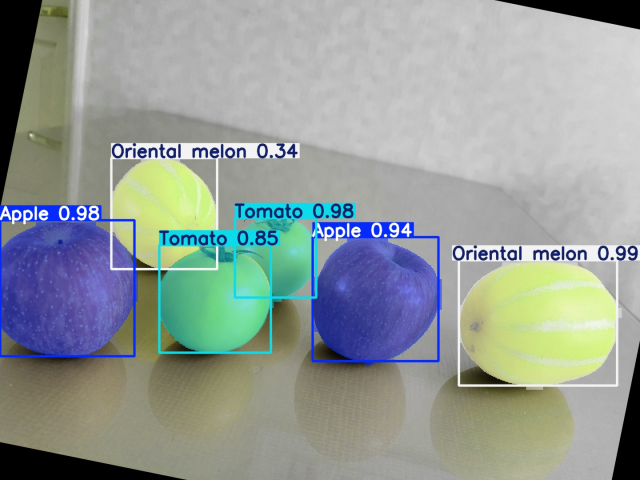

In [30]:
# 예측 이미지 확인
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/runs/segment/predict2/fruit03_aug_17_983a227b.jpg')
fix_width = 640
height,width = img.shape[:2]
ratio = fix_width / width
demension = (fix_width, int(height*ratio))
img = cv2.resize(img, demension, interpolation=cv2.INTER_AREA)
cv2_imshow(img)